In [27]:
import pyautogui
import win32gui
import win32con
import schedule
import time
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageGrab,Image

import ctypes
ctypes.windll.shcore.SetProcessDpiAwareness(2)

-2147024891

782 1202 1937 1802


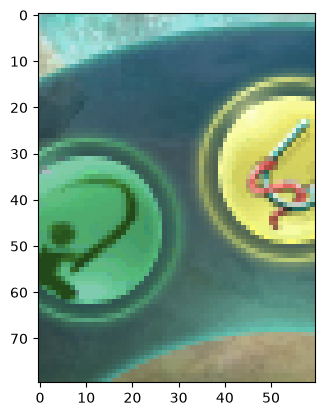

In [18]:
fish_width_start = 380
fish_width_end = 440
fish_height_start = 100
fish_height_end = 180

window_width = 800
window_height = 600

hwnd_list = []
def get_hwnd(hwnd, extra):
    title = win32gui.GetWindowText(hwnd)
    if ("幻唐志" in title) and ("RENDER" not in title):
        hwnd_list.append(hwnd)

def get_client_rect(hwnd):
    """
    获取窗口客户区的桌面坐标，不包括标题栏和边框
    返回: (left, top, right, bottom)
    """
    left, top = win32gui.ClientToScreen(hwnd, (0, 0))
    rect = win32gui.GetClientRect(hwnd)
    right = left + rect[2]
    bottom = top + rect[3]
    return left, top, right, bottom

def human_delay(base_seconds: float, sigma: float = 0.3) -> float:
    """模拟人类操作延迟，base_seconds 为中位数"""
    return max(0.05, random.lognormvariate(math.log(base_seconds), sigma))

win32gui.EnumWindows(get_hwnd, None)
assert len(hwnd_list) , "钓鱼只支持1个窗口"

hwnd = hwnd_list[0]
win32gui.ShowWindow(hwnd, win32con.SW_RESTORE)
win32gui.SetForegroundWindow(hwnd)

left, top, right, bottom = get_client_rect(hwnd)
time.sleep(human_delay(1))

print(left, top, right, bottom)
# game_image = ImageGrab.grab(bbox=(left,top , left + window_width , top + window_height))
game_image = ImageGrab.grab(bbox=(left+fish_width_start,top + fish_height_start, left+fish_width_end, top+fish_height_end))

plt.imshow(game_image)
plt.show()

In [49]:
has_fish = True

while has_fish:
    # game_image = ImageGrab.grab(bbox=(left+fish_width_start,top + fish_height_start, left+fish_width_end, top+fish_height_end))
    game_image = Image.open(r"C:\Users\27321\Desktop\1.png")
    try:
        start_fight_location = pyautogui.locate(str(r"C:\Users\27321\shenwu\resource\Fish\you_yu.png"),game_image, grayscale=True,confidence=0.7)
        abs_x = left + start_fight_location.left + start_fight_location.width // 2
        abs_y = top + start_fight_location.top + start_fight_location.height // 2

        pyautogui.moveTo(abs_x,abs_y, duration=human_delay(0.2))
        pyautogui.click()
        time.sleep(human_delay(1))
        has_fish = False

    except Exception as e:
        print(f"还未钓到鱼 {e}")
        time.sleep(human_delay(0.2))

In [46]:
game_image = Image.open(r"C:\Users\27321\Desktop\1.png")
image_array = np.array(game_image)
game_image = Image.fromarray(image_array[100:300,300:500,:])
start_fight_location = pyautogui.locate(str(r"C:\Users\27321\shenwu\resource\Fish\you_yu.png"),game_image, grayscale=True,confidence=0.5)
abs_x = left + start_fight_location.left + start_fight_location.width // 2
abs_y = top + start_fight_location.top + start_fight_location.height // 2


In [31]:
image_array = np.array(game_image)
image_array.shape

(600, 1155, 3)

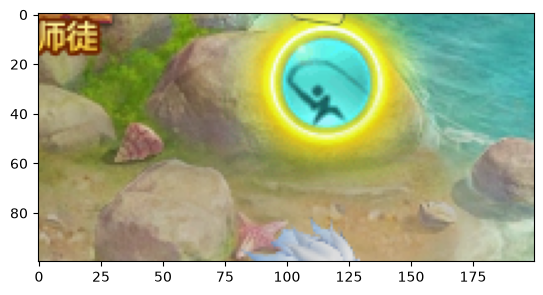

In [36]:
plt.imshow(image_array[100:200,300:500,:])
plt.show()